In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

#_set_env("OPENAI_API_KEY")
_set_env("GEMINI_API_KEY")

GEMINI_API_KEY:  ········


In [2]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

LANGSMITH_API_KEY:  ········


In [5]:
#from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

#llm = ChatOpenAI(model="gpt-4o")
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)
llm_with_tools=llm.bind_tools([multiply])

In [18]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state: MessagesState):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}

builder=StateGraph(MessagesState)
builder.add_node("decision",tool_calling_llm)
builder.add_node("tools",ToolNode([multiply]))
builder.add_edge(START, "decision")
builder.add_conditional_edges("decision",tools_condition,)
builder.add_edge("tools", END)

agent = builder.compile()

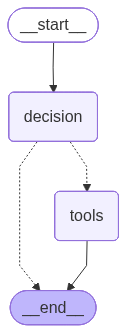

In [22]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [27]:
from langchain_core.messages import HumanMessage
def agent_call(msg: str) :
    input_msg=[HumanMessage(content=msg)]
    return agent.invoke({'messages':input_msg})

In [28]:
text='John makes 50 dollars per hour at work. Last week, he worked for 40 hours. How much did John make last week? '
results=agent_call(text)



In [29]:
for m in results['messages']:
    m.pretty_print()

================================ Human Message =================================

John makes 50 dollars per hour at work. Last week, he worked for 40 hours. How much did John make last week? 
================================== Ai Message ==================================
Tool Calls:
  multiply (70a6a40b-7e95-4e11-9b9d-205f202832dd)
 Call ID: 70a6a40b-7e95-4e11-9b9d-205f202832dd
  Args:
    a: 50
    b: 40
================================= Tool Message =================================
Name: multiply

2000
